<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">Datos Masivos II · PRÁCTICA 1</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Sección Dos: Hojas de Tomate</div><div style="opacity:.72;font-size:14px;margin-top:6px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div></div>

## Instrucciones 
Realizar una comparación entre: PCA, Non Negative Matrix y TSNE con los conjuntos de datos dados, así como una visualización de estos. 
Además, generar un clasificador o identificación de patrones, según sea el caso.

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0. Contexto. Clasificación de Hojas de Tomate: Identificación de infecciones en huerta. </span></div>

Esta base de datos se divide en dos conjuntos de datos de imágenes de hojas de tomate según diferentes fuentes. Las imágenes de hojas de tomate del primer conjunto de datos se seleccionaron de la base de datos `PlantVillage` con diez categorías (nueve categorías de **enfermedades** y una de **salud**). Las categorías detalladas del primer conjunto de datos son:
1. Mancha bacteriana,
2. Tizón temprano,
3. Saludable,
4. Tizón tardío,
5. Moho foliar,
6. Mancha foliar por Septoria,
7. Mancha diana,
8. Virus del mosaico del tomate,
9. Virus del rizado amarillo de la hoja del tomate,
10. Araña de dos manchas

El segundo conjunto de datos son imágenes de hojas de tomate de Taiwán, con seis categorías (cinco de **enfermedades** y una de **salud**). Incluye imágenes de una sola hoja, varias hojas, un fondo simple y un fondo complejo, con registros sintéticos creados a través de un método de aumento de datos para incrementar el número de imágenes. Tras la mejora de datos, se obtuvieron 4976 imágenes. Las categorías detalladas del segundo conjunto de datos son:
1. Mancha bacteriana,
2. Moho negro de la hoja,
3. Mancha gris de la hoja,
4. Sano,
5. Tizón tardío,
6. Oídio

Al realizar un aplanado, se obtienen instancias con **51,529 dimensiones**, que hace poco eficiente analizar una gran cantidad de información. Por ende, para facilitar la detección oportuna de enfermedades, se implementarán los algoritmos de reducción de dimensionalidad vistos en clase para disminuir la cantidad de atributos y se evaluará un clasificador para verificar la efectividad de la reducción.

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.1 Los Datos </span></div>

* `plant_village`: Conjunto de datos que cuenta con las 10 categorías originales en imágenes de dimensión $227\times227$. Contiene dos carpetas: `5 cross-validation`, con las imágenes ya divididas para validación cruzada de 5 pliegues, y `Preprocessed data`, con las imágenes preprocesadas antes de la división.
* `taiwan`: Conjunto con 6 categorías, de 662 imágenes originales (presentes y divididas en `Preprocessed data`) y 4976 totales (tras generar datos sintéticos, presentes y divididas en `data augmentation`).

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Preparación de Entorno  </span></div>

In [1]:
# Importación de Bibliotecas

# Rutas y acceso a carpetas
import os
from pathlib import Path

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [2]:
def perfilar_dataset_imagenes(ruta_base):
    """ 
    Función que escanea los archivos y devuelve un resumen en metadatos de todas las imágenes dentro del repositorio.

    Args:
        ruta_base (str): Dirección de la carpeta donde están presentes las imágenes.

    Returns:
        df_meta (pd.DataFrame): DataFrame con información general de las imágenes, como tamaño, etiqueta, peso, ruta
                                completa, etcétera.
    """
    metadatos = []
    ruta_path = Path(ruta_base)
    extensiones_validas = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    for ruta_img in ruta_path.rglob('*'):
        if ruta_img.suffix.lower() in extensiones_validas:
            categoria = ruta_img.parent.name
            try:
                with Image.open(ruta_img) as img:
                    ancho, alto = img.size
                    modo = img.mode
                    canales = len(img.getbands())
                    peso_kb = os.path.getsize(ruta_img) / 1024
                    
                    metadatos.append({
                        'archivo': ruta_img.name,
                        'categoria': categoria,
                        'ancho': ancho,
                        'alto': alto,
                        'canales': canales,
                        'modo': modo,
                        'peso_kb': peso_kb,
                        'ruta': str(ruta_img),
                        'corrupta': False
                    })
            except Exception as e:
                metadatos.append({
                    'archivo': ruta_img.name,
                    'categoria': categoria,
                    'ruta': str(ruta_img),
                    'corrupta': True,
                    'error': str(e)
                })
                
    df_meta = pd.DataFrame(metadatos)
    
    # Impresión del diagnóstico
    print("=" * 50)
    print("DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES")
    print("=" * 50)
    print(f"Total de imágenes detectadas: {len(df_meta)}")
    print(f"Imágenes corruptas: {df_meta['corrupta'].sum()}")
    
    print("\n--- Distribución por Categoría ---")
    print(df_meta['categoria'].value_counts())
    
    print("\n--- Resoluciones/Dimensiones Detectadas ---")
    print(df_meta[['ancho', 'alto', 'canales', 'modo']].drop_duplicates().to_string(index=False))
    
    return df_meta

In [3]:
def mostrar_grid_por_clase(df_meta, cols=5):
    """
    Muestra una cuadrícula con 1 imagen representativa de cada clase.
    """
    df_validas = df_meta[~df_meta['corrupta']]
    clases = df_validas['categoria'].unique()
    filas = (len(clases) + cols - 1) // cols
    
    fig, axes = plt.subplots(filas, cols, figsize=(cols * 3.5, filas * 3.5))
    axes = axes.flatten()
    
    for i, clase in enumerate(clases):
        sub_df = df_validas[df_validas['categoria'] == clase]
        ruta_img = sub_df.iloc[0]['ruta']
        img = Image.open(ruta_img)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{clase}\n{img.size[0]}x{img.size[1]} px", fontsize=9)
        axes[i].axis('off')
        
    # Ocultar subplots vacíos si la cuadrícula es mayor al número de clases
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

#### sample y metadatos

In [4]:
df_meta = perfilar_dataset_imagenes('./data')

DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES
Total de imágenes detectadas: 92784
Imágenes corruptas: 0

--- Distribución por Categoría ---
categoria
Tomato_Yellow_Leaf_Curl_Virus227    25716
Bacterial_spot227                   10212
Late_blight227                       9168
Septoria_leaf_spot227                8502
Two-spotted_spider_mite227           8046
healthy227                           7632
Target_Spot227                       6744
Early_blight227                      4800
Leaf_Mold227                         4572
Tomato_mosaic_virus227               1794
powdery mildew                       1413
Bacterial spot                        990
health                                954
Late blight                           882
Gray spot                             756
Black mold                            603
Name: count, dtype: int64

--- Resoluciones/Dimensiones Detectadas ---
 ancho  alto  canales modo
   227   227        3  RGB


In [5]:
df_meta.head()

,archivo,categoria,ancho,alto,canales,modo,peso_kb,ruta,corrupta
0,Bs10.JPG,Bacterial spot,227,227,3,RGB,9.355469,data\taiwan\Preprocessed data\Train\Bacterial ...,False
1,Bs100.JPG,Bacterial spot,227,227,3,RGB,9.326172,data\taiwan\Preprocessed data\Train\Bacterial ...,False
2,Bs101.JPG,Bacterial spot,227,227,3,RGB,8.189453,data\taiwan\Preprocessed data\Train\Bacterial ...,False
3,Bs102.JPG,Bacterial spot,227,227,3,RGB,10.067383,data\taiwan\Preprocessed data\Train\Bacterial ...,False
4,Bs103.JPG,Bacterial spot,227,227,3,RGB,9.800781,data\taiwan\Preprocessed data\Train\Bacterial ...,False


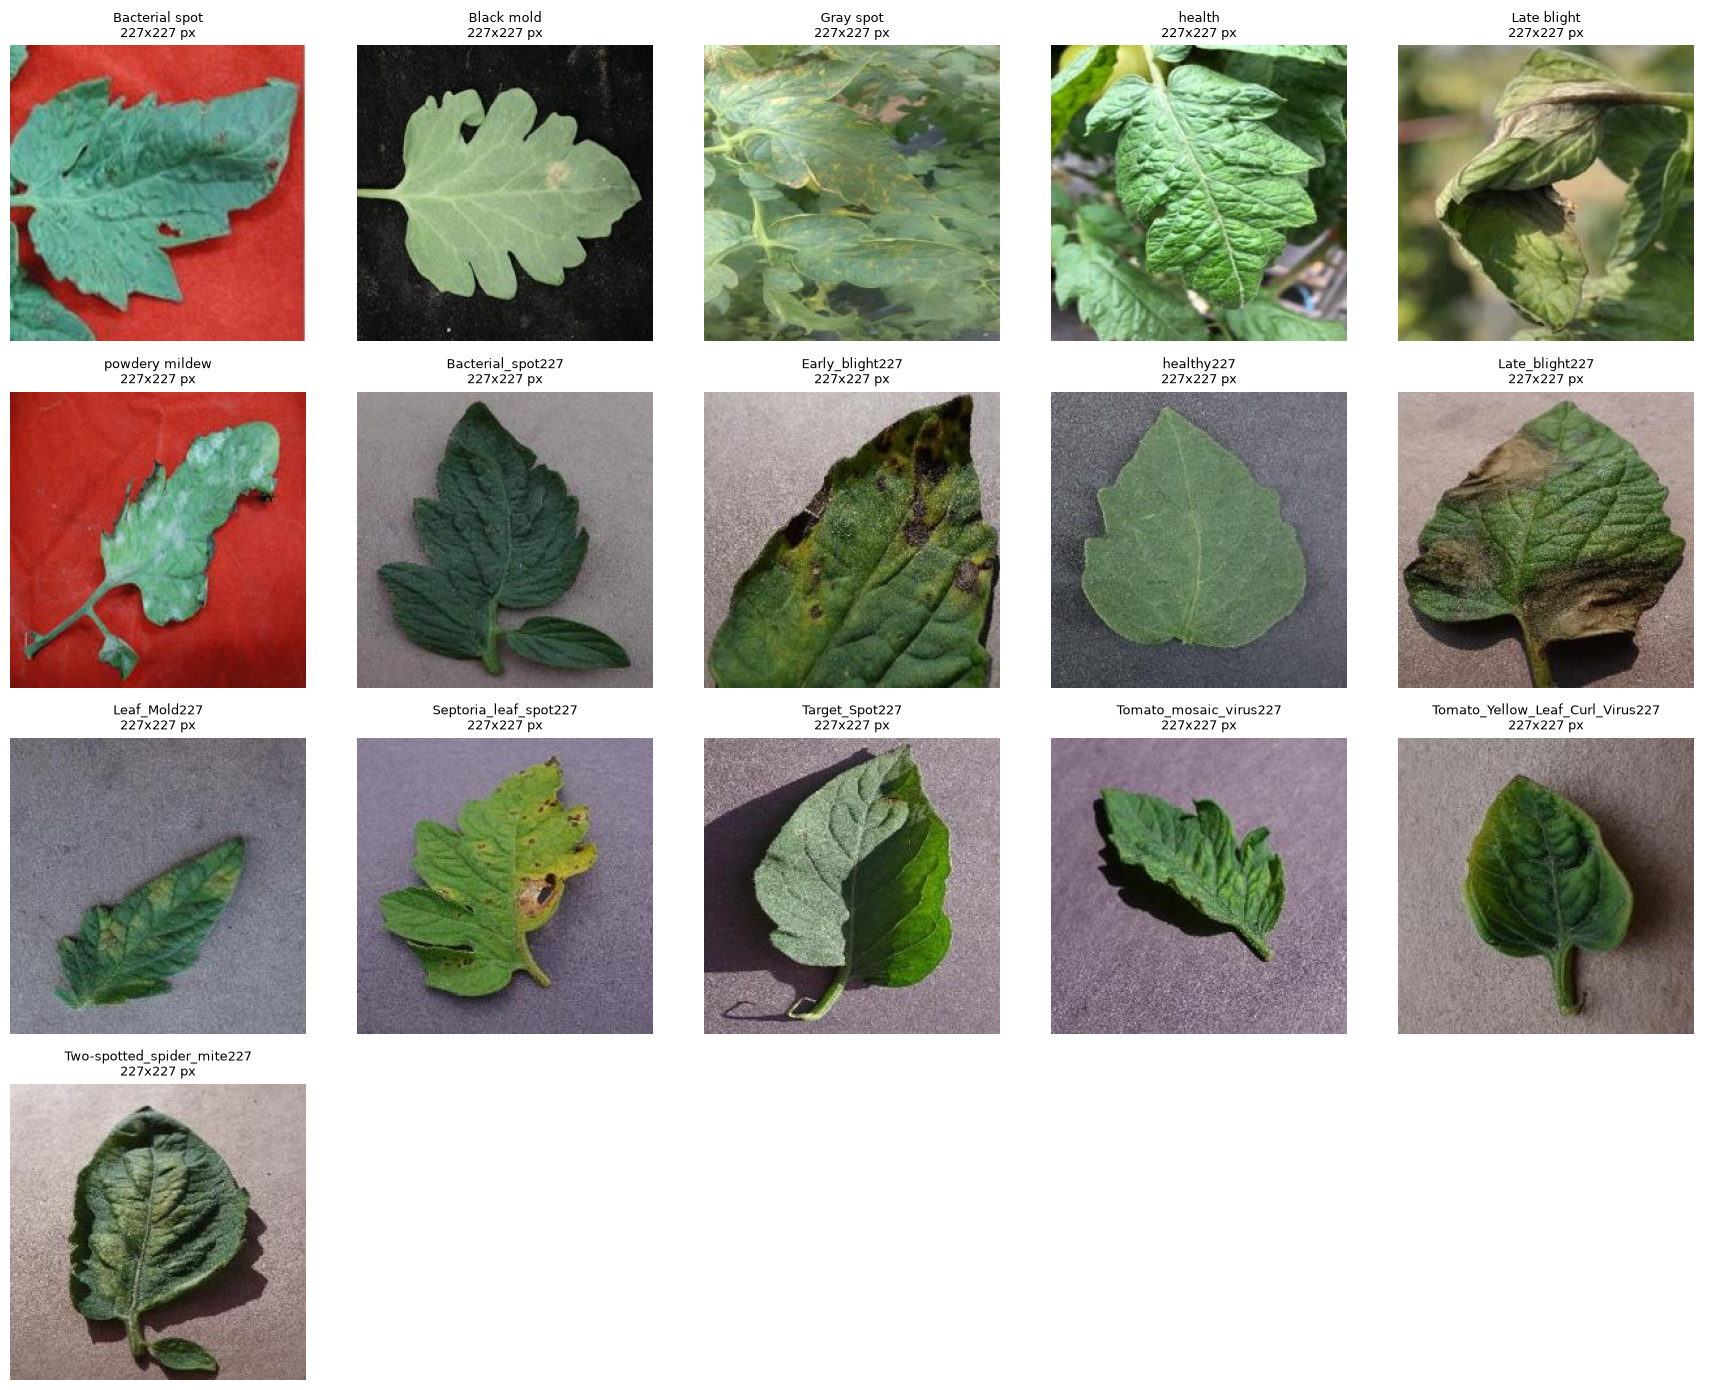

In [6]:
mostrar_grid_por_clase(df_meta)

In [8]:
def resumir_categorias_dataset(base_dir):
    extensiones = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.PNG', '.JPEG'}
    registros = []
    base_path = Path(base_dir)

    # Recorrer de forma recursiva todos los archivos de imagen
    for filepath in base_path.rglob('*'):
        if filepath.suffix in extensiones:
            # Convertir partes de la ruta a minúsculas para comparaciones robustas
            partes_ruta = [p.lower() for p in filepath.parts]
            
            # Categoría: nombre de la carpeta contenedora inmediata
            categoria = filepath.parent.name
            
            # Identificar si está en carpeta preprocesada
            es_preprocesado = any('preprocessed' in p for p in partes_ruta)
            
            # Identificar el conjunto Split
            if 'train' in partes_ruta:
                split = 'Train'
            elif 'test' in partes_ruta:
                split = 'Test'
            else:
                split = 'Sin Split'

            registros.append({
                'Categoria': categoria,
                'Preprocesado': 'Preprocesada' if es_preprocesado else 'No Preprocesada',
                'Split': split
            })

    df = pd.DataFrame(registros)

    if df.empty:
        print("No se encontraron imágenes en el directorio indicado.")
        return None

    # Crear tablas cruzadas para Preprocesamiento y Split
    df_pre = pd.crosstab(df['Categoria'], df['Preprocesado'])
    df_split = pd.crosstab(df['Categoria'], df['Split'])
    df_total = df.groupby('Categoria').size().to_frame(name='Total_Imagenes')

    # Unir todo en una sola vista estructurada
    df_resumen = pd.concat([df_pre, df_split, df_total], axis=1).fillna(0).astype(int)
    
    # Reordenar columnas para lectura clara
    cols_orden = []
    for col in ['No Preprocesada', 'Preprocesada', 'Train', 'Test', 'Sin Split']:
        if col in df_resumen.columns:
            cols_orden.append(col)
    cols_orden.append('Total_Imagenes')
    
    return df_resumen[cols_orden]

# Ejecución del resumen
df_categorias = resumir_categorias_dataset('./data')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df_categorias)

,No Preprocesada,Preprocesada,Train,Test,Sin Split,Total_Imagenes
Categoria,,,,,,
Bacterial spot,880,110,792,198,0,990
Bacterial_spot227,8510,1702,6808,1702,1702,10212
Black mold,536,67,481,122,0,603
Early_blight227,4000,800,3200,800,800,4800
Gray spot,672,84,604,152,0,756
Late blight,784,98,705,177,0,882
Late_blight227,7640,1528,6112,1528,1528,9168
Leaf_Mold227,3810,762,3048,762,762,4572
Septoria_leaf_spot227,7085,1417,5668,1417,1417,8502


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. Selección de datos</span></div>

#### Extracción, escala de grises y aplanado


In [9]:
import re

def extraer_metadatos_ruta(ruta_img, ruta_base):
    partes = ruta_img.relative_to(ruta_base).parts
    partes_lower = [p.lower() for p in partes]
    dataset = partes[0] if partes else 'desconocido'
    preprocesado = any('preprocessed' in p for p in partes_lower)
    if 'train' in partes_lower:
        split = 'Train'
    elif 'test' in partes_lower:
        split = 'Test'
    else:
        split = 'Sin Split'
    fold = None
    for p in partes:
        m = re.search(r'cross.?validation\D*(\d+)', p, flags=re.IGNORECASE)
        if m:
            fold = int(m.group(1))
            break

    categoria = ruta_img.parent.name

    return {
        'dataset': dataset,
        'preprocesado': preprocesado,
        'split': split,
        'fold': fold,
        'categoria': categoria,
    }


In [10]:
def cargar_dataset_aplanado(base_dir, tam_img=(227, 227), extensiones=None, mostrar_progreso=True):
    if extensiones is None:
        extensiones = {'.jpg', '.jpeg', '.png', '.bmp'}

    ruta_base = Path(base_dir)
    rutas_img = [p for p in ruta_base.rglob('*') if p.suffix.lower() in extensiones]
    n = len(rutas_img)
    n_pixeles = tam_img[0] * tam_img[1]

    if n == 0:
        raise ValueError(f"No se encontraron imágenes en {base_dir}")

    X = np.empty((n, n_pixeles), dtype=np.uint8)
    registros = []

    iterador = rutas_img
    if mostrar_progreso:
        try:
            iterador = tqdm(rutas_img, desc=f'Procesando {base_dir}')
        except ImportError:
            pass

    n_ok = 0
    for ruta_img in iterador:
        try:
            with Image.open(ruta_img) as img:
                img_gris = img.convert('L').resize(tam_img, Image.Resampling.LANCZOS)
                X[n_ok] = np.asarray(img_gris, dtype=np.uint8).flatten()
            meta = extraer_metadatos_ruta(ruta_img, ruta_base)
            meta['ruta'] = str(ruta_img)
            registros.append(meta)
            n_ok += 1
        except Exception as e:
            print(f"Imagen omitida por error ({ruta_img}): {e}")

    X = X[:n_ok]
    df_meta = pd.DataFrame(registros)

    return X, df_meta


Se procesa cada dataset por separado (`plantvillage` y `taiwan`) porque tienen categorías
distintas (10 vs. 6 clases) y probablemente se analizarán/entrenarán por separado más adelante.
Si en algún momento se quiere todo junto, basta con llamar `cargar_dataset_aplanado('./data')`.


In [11]:
X_plantvillage, meta_plantvillage = cargar_dataset_aplanado('./data/plantvillage')
X_taiwan, meta_taiwan = cargar_dataset_aplanado('./data/taiwan')

print("PlantVillage: ", X_plantvillage.shape, "-> filas:", len(meta_plantvillage))
print("Taiwan: ", X_taiwan.shape, "-> filas:", len(meta_taiwan))

display(meta_plantvillage.head())
display(meta_taiwan.head())


Procesando ./data/taiwan: 100%|██████████| 5598/5598 [00:04<00:00, 1255.66it/s]

PlantVillage:  (87186, 51529) -> filas: 87186
Taiwan:  (5598, 51529) -> filas: 5598


,dataset,preprocesado,split,fold,categoria,ruta
0,Preprocessed data,True,Sin Split,NaN,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
1,Preprocessed data,True,Sin Split,NaN,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
2,Preprocessed data,True,Sin Split,NaN,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
3,Preprocessed data,True,Sin Split,NaN,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...
4,Preprocessed data,True,Sin Split,NaN,Bacterial_spot227,data\plantvillage\Preprocessed data\Bacterial_...


,dataset,preprocesado,split,fold,categoria,ruta
0,Preprocessed data,True,Train,None,Bacterial spot,data\taiwan\Preprocessed data\Train\Bacterial ...
1,Preprocessed data,True,Train,None,Bacterial spot,data\taiwan\Preprocessed data\Train\Bacterial ...
2,Preprocessed data,True,Train,None,Bacterial spot,data\taiwan\Preprocessed data\Train\Bacterial ...
3,Preprocessed data,True,Train,None,Bacterial spot,data\taiwan\Preprocessed data\Train\Bacterial ...
4,Preprocessed data,True,Train,None,Bacterial spot,data\taiwan\Preprocessed data\Train\Bacterial ...


In [14]:
# Persistir a disco para no repetir el procesamiento cada vez
np.save('X_plantvillage.npy', X_plantvillage)
np.save('X_taiwan.npy', X_taiwan)
meta_plantvillage.to_csv('meta_plantvillage.csv', index=False)
meta_taiwan.to_csv('meta_taiwan.csv', index=False)

In [ ]:
# Para leer después:
# data_planvillage = np.load('X_plantvillage.npy')